# 💬 Sentiment Analysis Project

#### 🎯 1. Defining the Business Problem

This project begins by defining the **business problem** that needs to be solved.  
In Data Science, this step is extremely important because it connects **business needs** with **data-driven solutions**.

Before building any model, we need to clearly understand:

- ❓ **What problem we want to solve**
- 💡 **Why this problem matters for the company**
- 📏 **How success will be measured**

---

#### 🏢 Business Context

An **e-commerce company** receives thousands of product reviews from customers every day.

Currently, the analysis of these reviews is done **manually**, which creates several challenges:

- ⏳ **Slow analysis process**
- 💰 **High operational cost**
- 📈 **Difficulty scaling with the growing number of reviews**

Because of this, valuable customer feedback may take too long to be identified, making it harder for the company to react quickly to problems or opportunities.

---

#### 🎯 Project Objective

The goal of this project is to build a **Machine Learning model** capable of automatically classifying customer reviews into two categories:

- 😊 **Positive**
- 😡 **Negative**

By automating this process, the company will be able to analyze customer sentiment **faster, cheaper, and at scale**.

---

#### 🚀 Expected Business Benefits

**⚡ Efficiency**  
Reduce the time and cost associated with manual review analysis.

**📊 Faster Decision-Making**  
Enable product and marketing teams to quickly identify products with issues or opportunities for improvement.

**🎯 Better Prioritization**  
Automatically route **negative reviews** to the customer support team, allowing faster responses and improving the overall customer experience.

---

#### 📌 Introduction

Customer feedback is one of the most valuable sources of information for companies.  
However, when the volume of reviews grows significantly, manual analysis becomes inefficient and difficult to scale.

In this project, we apply **Natural Language Processing (NLP)** and **Machine Learning** techniques to build a **Sentiment Analysis model** capable of automatically classifying customer reviews as **positive** or **negative**.

This approach allows companies to **extract insights from large volumes of text data**, improving decision-making, operational efficiency, and customer satisfaction.

### 📥 Loading the Dataset and Libraries

Before we start, we need to install the necessary Python libraries and **load the dataset**.


In [1]:
# Install the required libraries
%pip install pandas numpy matplotlib seaborn scikit-learn -q 
# Install and update the watermark package to display environment and library version information
%pip install -q -U watermark

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Data manipulation and visualization
import re
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt

# Pre-Processing and Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [3]:
# Load the watermark extension
%reload_ext watermark

# Display metadata for your notebook
%watermark -a "Maykon - 💬 Sentiment Analysis Project" -d -u -v -p numpy,pandas,matplotlib,seaborn

Author: Maykon - 💬 Sentiment Analysis Project

Last updated: 2026-03-11

Python implementation: CPython
Python version       : 3.13.7
IPython version      : 9.10.0

numpy     : 2.4.2
pandas    : 3.0.1
matplotlib: 3.10.8
seaborn   : 0.13.2



In [4]:
# Load the Sentiment Analysis dataset from a local CSV file into a pandas DataFrame
data = r"data\dataset.csv"

df = pd.read_csv(data)

In [5]:
# It returns the dimensions of the DataFrame as a tuple
df.shape

(500, 3)

In [6]:
df.head() #Displays the first rows of the DataFrame df.

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
1,2,NaN,negativo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo


In [7]:
df.sample(15) # Random 15 rows

,review_id,texto_review,sentimento
427,428,ESTOU MUITO FRUSTRADO COM ESTA COMPRA. DINHEIR...,negativo
56,57,Recebi o mouse hoje. Vou começar a usar para v...,negativo
21,22,Não recomendo. A entrega foi lenta e o noteboo...,negativo
310,311,O notebook é horrível. O suporte ao cliente fo...,negativo
194,195,A cor do fone de ouvido é um pouco diferente d...,positivo
118,119,Estou muito frustrado com esta compra. Dinheir...,negativo
137,138,Ótimo custo-benefício. O fone de ouvido é ótim...,positivo
57,58,A cor do monitor é um pouco diferente do que e...,negativo
255,256,Péssima experiência. O notebook quebrou no pri...,negativo
484,485,Estou muito frustrado com esta compra. Dinheir...,negativo


In [8]:
df.tail() #Displays the last 5 rows of the DataFrame df.

,review_id,texto_review,sentimento
495,496,Odiei o teclado. Qualidade de baixa qualidade ...,negativo
496,497,Estou muito impressionado com a compra. O moni...,positivo
497,498,Não recomendo. A entrega demorou uma eternidad...,negativo
498,499,Estou muito arrependido com esta compra. Dinhe...,negativo
499,500,Ótimo custo-benefício. O cadeira gamer é incrí...,positivo


#### 4. 🔎📊 Exploratory Data Analysis (EDA)

The investigation phase Here, we dive into the data to uncover patterns, anomalies, and valuable insights 💡. We use graphs 📈 (such as comparing positive 😊 vs. negative 😠 sentiment) and statistical measures to better understand the distribution and characteristics of the data before making any modifications 🛠️.

In [9]:
# Information about the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   review_id     500 non-null    int64
 1   texto_review  488 non-null    str  
 2   sentimento    500 non-null    str  
dtypes: int64(1), str(2)
memory usage: 11.8 KB


In [10]:
df.describe(include='all').T  # Generates descriptive statistics for all numeric columns in your DataFrame.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
review_id,500.0,NaN,NaN,NaN,250.5,144.481833,1.0,125.75,250.5,375.25,500.0
texto_review,488,283,Estou muito frustrado com esta compra. Dinheir...,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentimento,500,2,positivo,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### Check for missing values on the DataFrame:

In [11]:
df.isna().sum()  # You can also use df.isnull().sum() — both do the same thing

review_id        0
texto_review    12
sentimento       0
dtype: int64


Distribution of Sentiments:



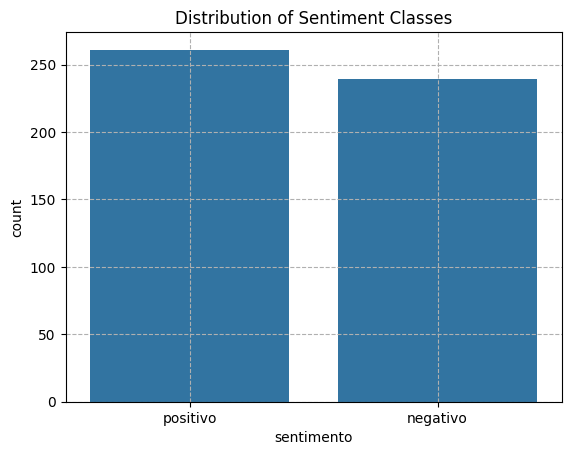

In [12]:
print("\nDistribution of Sentiments:\n")
sns.countplot(data = df, x = 'sentimento')
plt.title('Distribution of Sentiment Classes')
plt.grid(True, linestyle="--")
plt.show()

#### 5. 🧹 Data Cleaning

In this step, we correct the problems identified in the EDA 🔎. This includes handling missing values (e.g., removing the corresponding rows) 🗑️, ensuring that the data is in the correct format 📂, and applying the text cleaning function (dsa_clean_text) 🧼 to normalize the reviews ✍️ — removing accents, possible unwanted characters, and other noise characters 🚫.

In [13]:
# Remove rows with missing values
print(f"\nOriginal DataFrame size: {len(df)}")
df.dropna(subset = ['texto_review'], inplace = True)
dfc = df.copy() # It creates a deep copy of your DataFrame for precaution.
print(f"DataFrame size after removing nulls: {len(dfc)}")


Original DataFrame size: 500
DataFrame size after removing nulls: 488


In [14]:
# It returns the dimensions of the DataFrame as a tuple
dfc.shape

(488, 3)

In [15]:
dfc.head() #Displays the first rows of the DataFrame df.

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo


In [16]:
import re
import unicodedata

# Text Cleaning Function
def clean_text(text):
    """
    Complete text cleaning function:

    1. Convert to lowercase.
    2. Remove accents and cedillas.
    3. Remove numbers and special characters.
    4. Remove extra spaces.
    """

    # Ensure the text is a valid string (handle NaN or non-string values)
    if not isinstance(text, str):
        return ""

    # --- STEP 1: Normalize and remove accents ---
    text_without_accents = ''.join(
        c for c in unicodedata.normalize('NFKD', text)
        if unicodedata.category(c) != 'Mn'
    )

    # --- STEP 2: Cleaning with Regex ---
    clean_text = text_without_accents.lower()

    # Keep only letters and spaces
    clean_text = re.sub(r'[^a-z\s]', '', clean_text)

    # Remove extra spaces
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()

    return clean_text

# created by ChatGPT

In [17]:
#Apply the cleaning function
dfc['texto_limpo'] = dfc['texto_review'].apply(clean_text) 

In [18]:
dfc.head()

,review_id,texto_review,sentimento,texto_limpo
0,1,Estou muito feliz com a compra. O cadeira game...,positivo,estou muito feliz com a compra o cadeira gamer...
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo,nao recomendo a entrega foi lenta e o celular ...
3,4,O monitor é decepcionante. O suporte ao client...,positivo,o monitor e decepcionante o suporte ao cliente...
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo,e um livro ok pelo prceo que paguei
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo,nao rceomendo a entrega atrasou muito e o moni...


#### 6. ⚙️ Feature Engineering

This is the stage where we transform raw data into useful features for the model 🔄. In this project, this involves creating the clean_text column 🧼 and, more importantly, converting the text classes ('positive', 'negative') into a numerical format 🔢 (sentiment_label: 1, 0), which is what the Machine Learning algorithm can understand 🤖📊.

In [19]:
dfc.head()

,review_id,texto_review,sentimento,texto_limpo
0,1,Estou muito feliz com a compra. O cadeira game...,positivo,estou muito feliz com a compra o cadeira gamer...
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo,nao recomendo a entrega foi lenta e o celular ...
3,4,O monitor é decepcionante. O suporte ao client...,positivo,o monitor e decepcionante o suporte ao cliente...
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo,e um livro ok pelo prceo que paguei
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo,nao rceomendo a entrega atrasou muito e o moni...


In [20]:
# Mapping sentiment to numerical values ​​(Attribute Engineering)
dfc['sentiment_label'] = dfc['sentimento'].map({'positivo': 1, 'negativo': 0})

In [21]:
print("\nDataFrame after cleaning and mapping:\n")
dfc[['texto_limpo', 'sentiment_label']].head()


DataFrame after cleaning and mapping:



,texto_limpo,sentiment_label
0,estou muito feliz com a compra o cadeira gamer...,1
2,nao recomendo a entrega foi lenta e o celular ...,0
3,o monitor e decepcionante o suporte ao cliente...,1
4,e um livro ok pelo prceo que paguei,0
5,nao rceomendo a entrega atrasou muito e o moni...,1


In [22]:
dfc.head(15)

,review_id,texto_review,sentimento,texto_limpo,sentiment_label
0,1,Estou muito feliz com a compra. O cadeira game...,positivo,estou muito feliz com a compra o cadeira gamer...,1
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo,nao recomendo a entrega foi lenta e o celular ...,0
3,4,O monitor é decepcionante. O suporte ao client...,positivo,o monitor e decepcionante o suporte ao cliente...,1
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo,e um livro ok pelo prceo que paguei,0
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo,nao rceomendo a entrega atrasou muito e o moni...,1
6,7,Péssima experiência. O livro quebrou no primei...,negativo,pessima experiencia o livro quebrou no primeir...,0
7,8,Recebi o fone de ouvido hoje. Vou começar a us...,positivo,recebi o fone de ouvido hoje vou comecar a usa...,1
8,9,Estou muito arrependido com esta compra. Dinhe...,negativo,estou muito arrependido com esta compra dinhei...,0
9,10,Ótimo custo-benefício. O celular é excelente e...,positivo,otimo custobeneficio o celular e excelente e m...,1
10,11,Ótimo custo-benefício. O livro é fantástica e ...,positivo,otimo custobeneficio o livro e fantastica e mu...,1


#### 7. 📊 Separating Data into Training and Test Sets

An essential step for training and evaluating the model. We split the dataset into two parts: a larger training set, which the model uses to learn patterns, and a smaller test set, i usually use 80% of the data for training and 20% for testing, which is kept "hidden" from the model to simulate new data and evaluate its real performance after training 📈🤖. 

In [23]:
# Define variables X (input) and y (output)
X = dfc['texto_limpo']
y = dfc['sentiment_label']

In [24]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

#### 🚀 8. Predictive Modeling Pipeline
Here, we build an automated production pipeline for our model. The Scikit-learn pipeline encapsulates all preprocessing steps and the final model, ensuring that the same transformations are applied consistently to the training data and new incoming data. 🔄✨

🛠️ Core Components
TF-IDF Vectorization 🔡: Converts raw text into a meaningful numerical representation.

StandardScaler ⚖️: Normalizes features to ensure the model isn't biased by different scales.

Logistic Regression 📈: The final classification engine that makes the predictions.

🌟 Why This Matters
Consistency: Eliminates the risk of "data leakage" by keeping training and testing logic identical. 🛡️

Efficiency: Streamlines the transition from a messy notebook to a production-ready environment. ⚡

Maintainability: Keeps your codebase clean, modular, and easy to debug. 🧹

In [25]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=['de', 'a', 'o', 'que', 'e', 'do', 'da', 'in', 'um'])),
    ('scaler', StandardScaler(with_mean=False)), 
    ('logreg', LogisticRegression(solver='liblinear', random_state=42, max_iter=1000))
])

In [26]:
type(pipeline)

sklearn.pipeline.Pipeline

The pipeline consists of three sequential steps, each with a unique name (*_'tfidf', 'scaler', 'logreg'_*) and a specific function. ⚙️📦

##### 8.1. Vectorization of Text Data ('tfidf', TfidfVectorizer(...)) 🔡
What does it do? This is the first step, called 'tfidf'. It uses TfidfVectorizer to convert raw text into numbers. 🔢 It transforms each review into a numeric vector, where each number represents the "importance" of a word in that text relative to the entire collection. Common "filler" words like 'of', 'the', or 'a' are ignored using stop_words to keep the focus on meaningful terms. 🚫🐝

##### 8.2. Data Standardization ('scaler', StandardScaler(with_mean=False)) ⚖️
What does it do? The second step, 'scaler', takes the numeric vectors and standardizes them. The StandardScaler adjusts the scale of all numbers so they have a similar variance, preventing any single word from dominating the model just because of its numerical range. 📏 The parameter with_mean=False is essential here; since TF-IDF data is "sparse" (mostly zeros), this setting preserves that structure and prevents your computer from running out of memory. 🧠🛡️

##### 8.3. Machine Learning Model ('logreg', LogisticRegression(...)) 🤖
What does it do? The final step, 'logreg', is the classification engine itself. LogisticRegression receives the standardized numerical data and learns to make the final prediction: classifying the text as "positive" or "negative". ✅❌

#### 8.4. Hyperparameter Optimization

This is the fine-tuning of the model. Using GridSearchCV, we systematically test various combinations of configurations (hyperparameters) for the pipeline in order to find the combination that results in the best possible performance.

In [27]:
# Define the hyperparameter grid for optimization
parameters_grid = {
'tfidf__max_features': [500, 1000, 2000],
'tfidf__ngram_range': [(1, 1), (1, 2)],
'logreg__C': [0.1, 1, 10],
'logreg__penalty': ['l1', 'l2'],

'logreg__max_iter': [5000, 6000]
}

In [28]:
# Configure GridSearchCV
grid_search = GridSearchCV( 
pipeline, # Pipeline with preprocessing and model steps 
parameters_grid, # Dictionary with the hyperparameter combinations to be tested 
cv = 5, # Number of splits for cross-validation (5-fold cross-validation) 
n_jobs = -1, # Uses all available processor cores to speed up the process 
scoring = 'accuracy', # Metric used to evaluate the performance of each combination (here, accuracy) 
verbose = 1 # Detail level of output during execution (1 displays basic progress)
)

Cross-validation is a technique used to evaluate the performance of a model by dividing the dataset into several parts (or “folds”). The model is trained on some of these parts and tested on others, on a rotating basis. This allows performance to be measured in a more reliable and general way, preventing the result from depending only on a single division of the data.

#### 8.5. Model Training 🏋️‍♂️🤖

In this step, we feed the pipeline with training data 📚. GridSearchCV runs the .fit() process 🏃‍♂️, where the algorithm learns the patterns that connect the review text to their respective sentiments 😊😞.

In [29]:
print("\nStarting model training with hyperparameter optimization...\n")
grid_search.fit(X_train, y_train)


Starting model training with hyperparameter optimization...

Fitting 5 folds for each of 72 candidates, totalling 360 fits


c:\Users\LarTI\OneDrive\Desktop\Projects\Classification-model-for-sentiment-analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\LarTI\OneDrive\Desktop\Projects\Classification-model-for-sentiment-analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logreg__C': [0.1, 1, ...], 'logreg__max_iter': [5000, 6000], 'logreg__penalty': ['l1', 'l2'], 'tfidf__max_features': [500, 1000, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [30]:
print("\nBest hyperparameters found:\n")
print(grid_search.best_params_)


Best hyperparameters found:

{'logreg__C': 0.1, 'logreg__max_iter': 5000, 'logreg__penalty': 'l1', 'tfidf__max_features': 500, 'tfidf__ngram_range': (1, 1)}


In [31]:
# Get the best model
best_model = grid_search.best_estimator_

In [32]:
type(best_model)

sklearn.pipeline.Pipeline

#### 9. Model Evaluation and Metrics Interpretation

This is the final test.🧪
We use the test set (the data the model has never seen) to make predictions and compare them with the actual results 📊.

Metrics such as Accuracy 🎯, Classification Report 📑, and the Confusion Matrix 🔢 help us evaluate how well the model is generalizing to new data and whether it meets the business objectives 💼.

In [33]:
# Predictions on the test set
y_pred = best_model.predict(X_test)

In [34]:
# Calculate the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names = ['Negative', 'Positive'])

In [35]:
print(f"\nModel Accuracy: {accuracy:.2%}\n")
print("Classification Report:\n")
print(report)


Model Accuracy: 80.61%

Classification Report:

              precision    recall  f1-score   support

    Negative       0.79      0.80      0.80        46
    Positive       0.82      0.81      0.82        52

    accuracy                           0.81        98
   macro avg       0.81      0.81      0.81        98
weighted avg       0.81      0.81      0.81        98



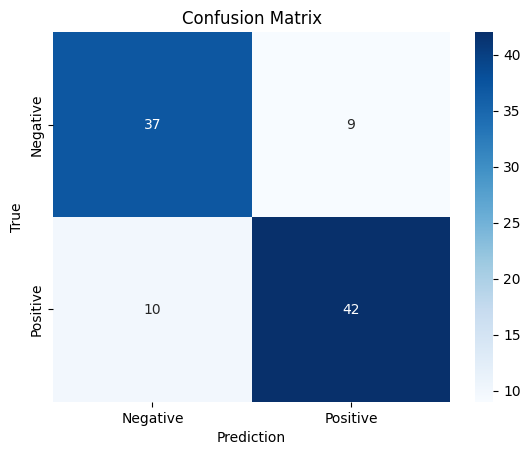

In [36]:
# Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',

xticklabels = ['Negative', 'Positive'],

yticklabels = ['Negative', 'Positive'])
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

**1. Accuracy**

Of all the reviews (positive and negative) that the model analyzed, what is the total percentage of correct classifications?

In our context: If you ran 100 reviews through the model and it correctly classified 92 of them (regardless of whether they were positive or negative), the accuracy is 92%. It is the most general measure of performance.

**2. Precision**

This metric is calculated for each class.

Precision for the 'Positive' class: Of the reviews that the model labeled as 'Positive', how many were actually positive?

In our context: If the model marked 10 reviews as "Positive", but only 9 of them were actually positive (and 1 was an error, a false positive), the precision for the 'Positive' class is 90%.

Importance: High precision here means you can trust the "Positive" label. If you're going to use these reviews in marketing materials, for example, you don't want to accidentally show a negative review.

Precision for the 'Negative' class: Of the reviews the model labeled as 'Negative', how many were actually Negative?

In our context: If the model marked 10 reviews as "Negative" and all 10 were in fact negative, the precision for the 'Negative' class is 100%.

Importance: Essential for the support team. High precision here ensures that the team's time is not spent analyzing reviews that were actually positive (false negatives for the support team).

**3. Recall**

This metric is also calculated for each class.

Recall for the 'Positive' class: Of all the reviews that were actually Positive, how many did your model manage to find?

In our context: If there were 12 positive reviews in total, but your model only managed to identify 9 of them (missing 3), the recall for the 'Positive' class is 75% (9 out of 12).

Importance: A high recall here ensures you are capturing most of the positive feedback. You are not missing the opportunity to identify satisfied customers.

Recall for the 'Negative' class: Of all the reviews that were actually negative, how many did your model manage to find?

In our context: If there were 10 dissatisfied customers (negative reviews), and the model identified 9 of them, the recall for 'Negative' is 90%. It "missed" one dissatisfied customer.

Importance: Perhaps the most critical metric for crisis management. A high recall for 'Negative' is vital to ensure that almost no complaint goes unnoticed and that the support team can act. **4. F1-Score**

What is the balanced ratio between Precision and Recall for each class?

In our context: It's a single score that combines the two previous metrics. The F1-Score for the 'Positive' class will only be high if both the precision and recall for 'Positive' are high. It avoids the scenario where a model is excellent in one metric but terrible in another. It is often the best metric to evaluate the model's performance in a specific class.

**5. Support**

How many reviews for each class actually existed in my test set?

In our context: If the report shows a support of 58 for 'Positive' and 62 for 'Negative', it means that in your test dataset there were 58 positive reviews and 62 negative reviews.

Importance: Provides context to the results. If a class's support is very low, the performance metrics for that class are less reliable, as they were calculated based on few examples.

In [37]:
# If we are satisfied with the model's performance, we save it to disk:
joblib.dump(best_model, 'model_sentiment_v1.joblib')

['model_sentiment_v1.joblib']

In [38]:
# You can delete the trained model and remove it from memory
del best_model